# 10 — Búsqueda de lugares, autores, enfermedades y medicamentos

Equivalente al notebook `12_busqueda_lugares_personajes.ipynb` de Karen,  
adaptado al dominio de salud.

**Busca por regex:**
- Departamentos de Colombia y ciudades principales
- Instituciones de salud colombianas e internacionales
- Autores / figuras clave en salud pública (equivalente a autores literarios de Karen)
- Enfermedades
- Medicamentos

**Entrada:** `corpus_cleaned.parquet`, `salud_tweets_final.parquet`, `salud_ner.parquet`  
**Salida:** parquet + Excel multi-hoja con todos los resultados


In [2]:
# ============================================================
# CELL 0 — CONFIG
# ============================================================
from pathlib import Path

DATA_PROCESSED = Path(r'C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosPropios')

print('[CONFIG] OK')


[CONFIG] OK


In [3]:
# ============================================================
# CELL 1 — IMPORTS Y CARGA
# ============================================================
import re
import unicodedata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Corpus completo
corpus = pd.read_parquet(DATA_PROCESSED / 'corpus_cleaned.parquet')
corpus['Fecha'] = pd.to_datetime(corpus['Fecha'], errors='coerce')

# Subcorpus de salud
tweets_salud = pd.read_parquet(DATA_PROCESSED / 'salud_tweets_final.parquet')

# Merge para obtener texto
df_salud = tweets_salud.merge(
    corpus[['id_doc', 'Texto_limpio', 'Fecha', 'Author_Normalized', 'Entidad']],
    on='id_doc', how='left'
)
df_salud['Anio'] = df_salud['Fecha'].dt.year

print(f'Tweets de salud: {len(df_salud):,}')
df_salud.head(2)


Tweets de salud: 29,230


,chunk_id,id_doc,texto_chunk,Salud_Control_alimentos,Salud_Economia_salud,Salud_Epidemiologia,Salud_Estadisticas_sanitarias,Salud_Higiene,Salud_Higiene_ambiental,Salud_Lucha_enfermedades,...,Salud_Toxicomania,score_max,subcat_max,etiqueta_salud,categoria_detectada,Texto_limpio,Fecha,Author_Normalized,Entidad,Anio
0,4_1,4,"Normas que deberán cumplirse en las empresas, ...",0.384811,0.318987,0.45166,0.329303,0.388348,0.346759,0.380169,...,0.056038,0.451660,Salud_Epidemiologia,1,Salud_Epidemiologia,"Normas que deberán cumplirse en las empresas, ...",2020-06-03,@hamacazulia,Doctor o profesional de salud,2020
1,6_1,6,La otra semana ya saldrá el aumento de contagi...,0.301033,0.242711,0.42305,0.349399,0.381581,0.292549,0.477993,...,0.102819,0.477993,Salud_Lucha_enfermedades,1,Salud_Lucha_enfermedades,La otra semana ya saldrá el aumento de contagi...,2020-06-03,@bebita11385037,Autoridad local de salud o gobierno,2020


In [4]:
# ============================================================
# CELL 2 — DICCIONARIOS DE TÉRMINOS
# (equivalente a los Excel externos de Karen)
# ============================================================

# --- Departamentos de Colombia ---
departamentos = {
    'Amazonas'          : ['Amazonas'],
    'Antioquia'         : ['Antioquia', 'Medellin', 'Medellín'],
    'Arauca'            : ['Arauca'],
    'Atlántico'         : ['Atlantico', 'Barranquilla'],
    'Bolívar'           : ['Bolivar', 'Cartagena'],
    'Boyacá'            : ['Boyaca', 'Tunja'],
    'Caldas'            : ['Caldas', 'Manizales'],
    'Caquetá'           : ['Caqueta', 'Florencia'],
    'Casanare'          : ['Casanare', 'Yopal'],
    'Cauca'             : ['Cauca', 'Popayan'],
    'Cesar'             : ['Cesar', 'Valledupar'],
    'Chocó'             : ['Choco', 'Quibdo'],
    'Córdoba'           : ['Cordoba', 'Monteria'],
    'Cundinamarca'      : ['Cundinamarca', 'Bogota', 'Bogotá'],
    'Guainía'           : ['Guainia'],
    'Guaviare'          : ['Guaviare'],
    'Huila'             : ['Huila', 'Neiva'],
    'La Guajira'        : ['Guajira', 'Riohacha'],
    'Magdalena'         : ['Magdalena', 'Santa Marta'],
    'Meta'              : ['Meta', 'Villavicencio'],
    'Nariño'            : ['Narino', 'Pasto'],
    'Norte de Santander': ['Norte de Santander', 'Cucuta', 'Cúcuta'],
    'Putumayo'          : ['Putumayo', 'Mocoa'],
    'Quindío'           : ['Quindio', 'Armenia'],
    'Risaralda'         : ['Risaralda', 'Pereira'],
    'San Andrés'        : ['San Andres'],
    'Santander'         : ['Santander', 'Bucaramanga'],
    'Sucre'             : ['Sucre', 'Sincelejo'],
    'Tolima'            : ['Tolima', 'Ibague', 'Ibagué'],
    'Valle del Cauca'   : ['Valle del Cauca', 'Cali'],
    'Vaupés'            : ['Vaupes', 'Mitu'],
    'Vichada'           : ['Vichada'],
}

# --- Instituciones de salud colombianas e internacionales ---
instituciones = {
    'Ministerio de Salud'        : ['Ministerio de Salud', 'MinSalud', 'Minsalud'],
    'INS'                        : ['INS', 'Instituto Nacional de Salud'],
    'INVIMA'                     : ['INVIMA', 'Invima'],
    'Secretaría de Salud'        : ['Secretaria de Salud', 'Secretaría de Salud', 'SecSalud'],
    'OMS/OPS'                    : ['OMS', 'OPS', 'PAHO', 'WHO'],
    'UNICEF'                     : ['UNICEF', 'Unicef'],
    'Cruz Roja'                  : ['Cruz Roja'],
    'EPS'                        : ['EPS'],
    'IPS'                        : ['IPS'],
    'ICBF'                       : ['ICBF'],
    'Médicos Sin Fronteras'      : ['Medicos Sin Fronteras', 'MSF'],
    'Sura'                       : ['Sura', 'EPS Sura'],
    'Colsanitas'                 : ['Colsanitas'],
    'Nueva EPS'                  : ['Nueva EPS'],
    'Coomeva'                    : ['Coomeva'],
    'Presidencia'                : ['Presidencia', 'Presidente'],
    'Hospital/Clínica'           : ['Hospital', 'Clínica', 'Clinica', 'UCI', 'UTI'],
    'SGSSS'                      : ['SGSSS', 'Sistema General de Seguridad Social'],
}

# --- Autores / figuras clave en salud pública ---
# Equivalente a los autores literarios de Karen.
# Personas relevantes en el debate de salud publica colombiana
# durante la pandemia COVID-19 (marzo-agosto 2020).
# Fuente: investigacion sobre actores del sector salud en Colombia 2020.
#
# NOTA: Las EPS como instituciones ya estan en el diccionario 'instituciones'.
# Aqui van sus directivos y las figuras personales del debate publico.
autores_salud = {
    # ── Gobierno Nacional ──────────────────────────────────────────────────
    'Iván Duque'              : ['Ivan Duque', 'Iván Duque', 'Duque Márquez',
                                 'Duque Marquez'],
    'Fernando Ruiz'           : ['Fernando Ruiz', 'Ruiz Gomez', 'Ruiz Gómez',
                                 'Fernando Ruiz Gomez'],

    # ── INS ───────────────────────────────────────────────────────────────
    'Martha Ospina'           : ['Martha Ospina', 'Martha Lucia Ospina',
                                 'Martha Lucía Ospina', 'Ospina Martínez',
                                 'Ospina Martinez'],

    # ── Alcaldes (posesionados enero 2020) ────────────────────────────────
    'Claudia López'           : ['Claudia Lopez', 'Claudia López'],
    'Daniel Quintero'         : ['Daniel Quintero', 'Quintero Calle'],
    'Jorge Iván Ospina'       : ['Jorge Ivan Ospina', 'Jorge Ospina'],
    'Jaime Pumarejo'          : ['Jaime Pumarejo', 'Pumarejo'],
    'William Dau'             : ['William Dau', 'Dau'],

    # ── Gobernadores ──────────────────────────────────────────────────────
    'Aníbal Gaviria'          : ['Anibal Gaviria', 'Aníbal Gaviria',
                                 'Gaviria Correa'],      # Antioquia (se contagió)
    'Luis Fernando Suárez'    : ['Luis Fernando Suarez', 'Luis Fernando Suárez'],

    # ── Directivos EPS ────────────────────────────────────────────────────
    'José Fernando Cardona'   : ['Jose Fernando Cardona', 'Cardona'],  # Nueva EPS
    'Juan Gonzalo López'      : ['Juan Gonzalo Lopez', 'Juan Gonzalo López'],  # Salud Total / ACEMI
    'Sergio Martínez'         : ['Sergio Martinez', 'Sergio Martínez'],  # Sanitas / Keralty

    # ── Organismos internacionales ────────────────────────────────────────
    'Tedros Adhanom'          : ['Tedros', 'Tedros Adhanom', 'Director OMS'],

    # ── Expertos / voceros médicos ────────────────────────────────────────
    'Carlos Álvarez'          : ['Carlos Alvarez', 'Carlos Álvarez'],  # intensivista vocero COVID
    'Alejandro Gaviria'       : ['Alejandro Gaviria'],  # exministro, rector Uniandes
}

# --- Enfermedades ---
enfermedades = {
    'COVID-19'          : ['covid', 'covid19', 'covid-19', 'coronavirus', 'sars-cov-2',
                            'sars cov 2', 'pandemia', 'virus corona'],
    'Dengue'            : ['dengue'],
    'Malaria'           : ['malaria', 'paludismo'],
    'Tuberculosis'      : ['tuberculosis', 'TBC', 'TB'],
    'Hipertensión'      : ['hipertension', 'hipertensión', 'presion arterial', 'presión arterial'],
    'Diabetes'          : ['diabetes', 'diabetico', 'diabético'],
    'Cáncer'            : ['cancer', 'cáncer', 'tumor', 'oncologico', 'oncológico'],
    'VIH/SIDA'          : ['VIH', 'SIDA', 'HIV', 'AIDS'],
    'Influenza'         : ['influenza', 'gripa', 'gripe'],
    'Neumonía'          : ['neumonia', 'neumonía', 'pulmonía', 'pulmonia'],
    'Depresión'         : ['depresion', 'depresión', 'trastorno mental', 'salud mental'],
    'Zika'              : ['zika'],
    'Chikungunya'       : ['chikungunya'],
    'Fiebre Amarilla'   : ['fiebre amarilla'],
    'Sarampión'         : ['sarampion', 'sarampión'],
    'Varicela'          : ['varicela'],
    'Hepatitis'         : ['hepatitis'],
    'Chagas'            : ['chagas', 'tripanosomiasis'],
    'Leishmaniasis'     : ['leishmaniasis', 'leishmaniasis cutanea'],
    'Obesidad'          : ['obesidad', 'sobrepeso'],
}

# --- Medicamentos ---
medicamentos = {
    'Ivermectina'        : ['ivermectina', 'ivermectin'],
    'Hidroxicloroquina'  : ['hidroxicloroquina', 'hydroxychloroquine', 'cloroquina', 'chloroquine'],
    'Dexametasona'       : ['dexametasona', 'dexamethasone'],
    'Remdesivir'         : ['remdesivir'],
    'Vacuna Pfizer'      : ['pfizer', 'biontech'],
    'Vacuna Moderna'     : ['moderna'],
    'Vacuna AstraZeneca' : ['astrazeneca', 'oxford', 'covishield'],
    'Vacuna Sinovac'     : ['sinovac', 'coronavac'],
    'Vacuna Janssen'     : ['janssen', 'johnson'],
    'Vacuna Sputnik'     : ['sputnik'],
    'Ibuprofeno'         : ['ibuprofeno', 'ibuprofen'],
    'Acetaminofén'       : ['acetaminofen', 'acetaminofén', 'paracetamol', 'tylenol'],
    'Azitromicina'       : ['azitromicina', 'azithromycin'],
    'Plasma'             : ['plasma convaleciente', 'plasma de convaleciente'],
    'Oxígeno'            : ['oxigeno', 'oxígeno', 'tanque de oxigeno', 'concentrador'],
    'Anticoagulante'     : ['anticoagulante', 'heparina'],
    'Insulina'           : ['insulina'],
    'Antibiótico'        : ['antibiotico', 'antibiótico', 'amoxicilina'],
}

print(f'Departamentos  : {len(departamentos)}')
print(f'Instituciones  : {len(instituciones)}')
print(f'Autores salud  : {len(autores_salud)}')
print(f'Enfermedades   : {len(enfermedades)}')
print(f'Medicamentos   : {len(medicamentos)}')


Departamentos  : 32
Instituciones  : 18
Autores salud  : 16
Enfermedades   : 20
Medicamentos   : 18


In [5]:
# ============================================================
# CELL 3 — FUNCIÓN DE NORMALIZACIÓN Y BÚSQUEDA
# (Replica de Karen — misma lógica, adaptada a tweets)
# ============================================================

def normalizar_texto(texto: str) -> str:
    """Minúsculas, sin tildes, sin puntos."""
    texto = texto.lower()
    texto = unicodedata.normalize('NFD', texto)
    texto = ''.join(c for c in texto if unicodedata.category(c) != 'Mn')
    texto = texto.replace('.', '')
    return texto


def buscar_terminos(df_tweets: pd.DataFrame,
                    diccionario: dict,
                    col_salida: str) -> pd.DataFrame:
    """
    Busca términos (diccionario: {nombre_canonico: [variantes]})
    en el texto de los tweets.

    Retorna DataFrame con col_salida, id_doc, autor, fecha, variante hallada, texto.
    """
    textos_norm = df_tweets['Texto_limpio'].fillna('').map(normalizar_texto).to_numpy()
    id_docs     = df_tweets['id_doc'].to_numpy()
    autores     = df_tweets['Author_Normalized'].to_numpy()
    fechas      = df_tweets['Fecha'].to_numpy()
    subcats     = df_tweets['categoria_detectada'].to_numpy()
    textos_orig = df_tweets['Texto_limpio'].fillna('').to_numpy()

    resultados = []

    for nombre_canon, variantes in diccionario.items():
        variantes_norm = [normalizar_texto(v) for v in variantes if v.strip()]
        patron = re.compile(
            r'\b(' + '|'.join(re.escape(v) for v in variantes_norm) + r')\b'
        )

        for idx in range(len(textos_norm)):
            m = patron.search(textos_norm[idx])
            if m:
                resultados.append({
                    col_salida         : nombre_canon,
                    'Variante_hallada' : m.group(0),
                    'id_doc'           : id_docs[idx],
                    'autor'            : autores[idx],
                    'Fecha'            : fechas[idx],
                    'categoria_detectada': subcats[idx],
                    'Texto_limpio'     : textos_orig[idx],
                })

    df_res = pd.DataFrame(resultados)
    if not df_res.empty:
        df_res = (
            df_res
            .drop_duplicates(subset=[col_salida, 'id_doc'])
            .reset_index(drop=True)
        )
    return df_res


In [6]:
# ============================================================
# CELL 4 — BÚSQUEDA EN EL SUBCORPUS DE SALUD
# Equivalente a Karen: buscar lugares, personajes, autores, obras
# ============================================================

print('Buscando departamentos...')
df_res_depto = buscar_terminos(df_salud, departamentos, 'Departamento')
print(f'  Departamentos : {len(df_res_depto):,} menciones')

print('Buscando instituciones...')
df_res_inst = buscar_terminos(df_salud, instituciones, 'Institucion')
print(f'  Instituciones : {len(df_res_inst):,} menciones')

print('Buscando autores / figuras clave...')
df_res_autores = buscar_terminos(df_salud, autores_salud, 'Autor_salud')
print(f'  Autores       : {len(df_res_autores):,} menciones')

print('Buscando enfermedades...')
df_res_enf = buscar_terminos(df_salud, enfermedades, 'Enfermedad')
print(f'  Enfermedades  : {len(df_res_enf):,} menciones')

print('Buscando medicamentos...')
df_res_med = buscar_terminos(df_salud, medicamentos, 'Medicamento')
print(f'  Medicamentos  : {len(df_res_med):,} menciones')


Buscando departamentos...
  Departamentos : 4,152 menciones
Buscando instituciones...
  Instituciones : 3,059 menciones
Buscando autores / figuras clave...
  Autores       : 79 menciones
Buscando enfermedades...
  Enfermedades  : 29,621 menciones
Buscando medicamentos...
  Medicamentos  : 509 menciones


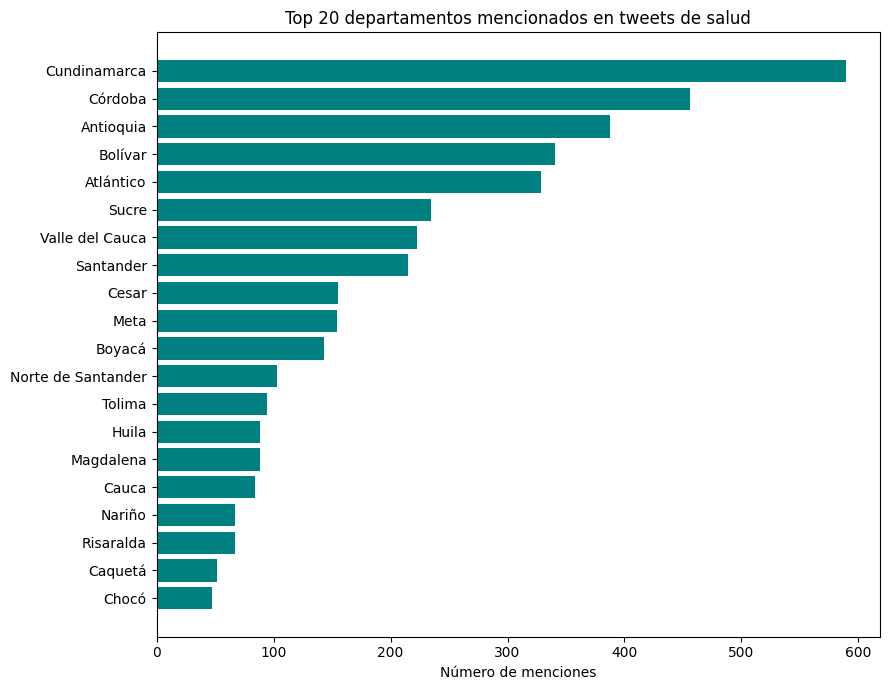

[GUARDADO] fig_top_departamentos_salud.png
      Departamento  Frecuencia
      Cundinamarca         589
           Córdoba         456
         Antioquia         388
           Bolívar         341
         Atlántico         329
             Sucre         235
   Valle del Cauca         223
         Santander         215
             Cesar         155
              Meta         154
            Boyacá         143
Norte de Santander         103
            Tolima          94
         Magdalena          88
             Huila          88
             Cauca          84
         Risaralda          67
            Nariño          67
           Caquetá          52
             Chocó          47


In [7]:
# ============================================================
# CELL 5 — TOP DEPARTAMENTOS
# ============================================================
freq_depto = (
    df_res_depto.groupby('Departamento').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_depto_top = freq_depto.head(20)
freq_depto_top_sorted = freq_depto_top.sort_values('Frecuencia', ascending=True)
ax.barh(freq_depto_top_sorted['Departamento'], freq_depto_top_sorted['Frecuencia'], color='teal')
ax.set_title('Top 20 departamentos mencionados en tweets de salud')
ax.set_xlabel('Número de menciones')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_departamentos_salud.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_departamentos_salud.png')
print(freq_depto.head(20).to_string(index=False))


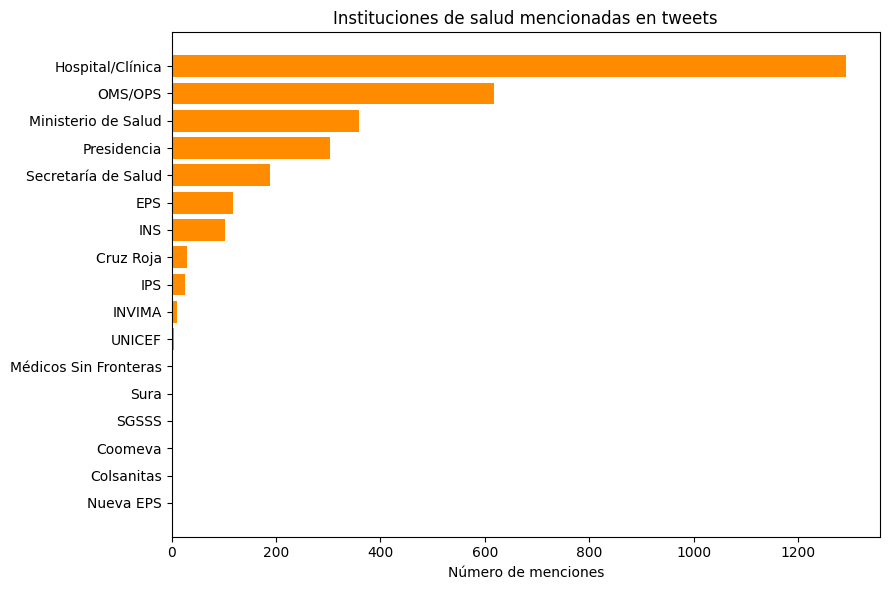

[GUARDADO] fig_top_instituciones_salud.png
          Institucion  Frecuencia
     Hospital/Clínica        1292
              OMS/OPS         617
  Ministerio de Salud         358
          Presidencia         304
  Secretaría de Salud         188
                  EPS         118
                  INS         102
            Cruz Roja          30
                  IPS          26
               INVIMA          11
               UNICEF           5
Médicos Sin Fronteras           2
                 Sura           2
           Colsanitas           1
              Coomeva           1
            Nueva EPS           1
                SGSSS           1


In [8]:
# ============================================================
# CELL 6 — TOP INSTITUCIONES
# ============================================================
freq_inst = (
    df_res_inst.groupby('Institucion').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
freq_inst_s = freq_inst.sort_values('Frecuencia', ascending=True)
ax.barh(freq_inst_s['Institucion'], freq_inst_s['Frecuencia'], color='darkorange')
ax.set_title('Instituciones de salud mencionadas en tweets')
ax.set_xlabel('Número de menciones')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_instituciones_salud.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_instituciones_salud.png')
print(freq_inst.to_string(index=False))


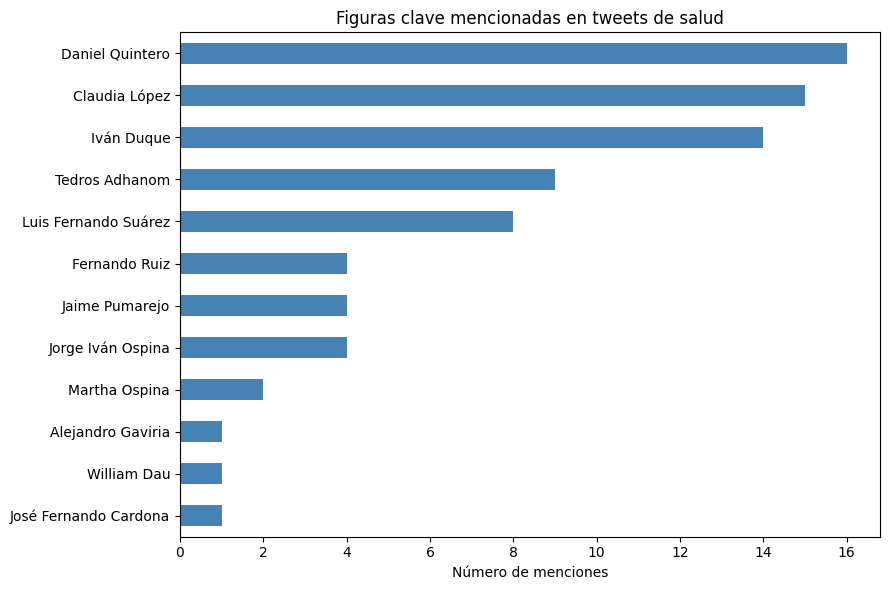

[GUARDADO] fig_top_autores_salud_busqueda.png
          Autor_salud  Frecuencia
      Daniel Quintero          16
        Claudia López          15
           Iván Duque          14
       Tedros Adhanom           9
 Luis Fernando Suárez           8
        Fernando Ruiz           4
    Jorge Iván Ospina           4
       Jaime Pumarejo           4
        Martha Ospina           2
    Alejandro Gaviria           1
José Fernando Cardona           1
          William Dau           1


In [9]:
# ============================================================
# CELL 5b — TOP AUTORES / FIGURAS CLAVE
# Equivalente a la búsqueda de autores literarios de Karen
# ============================================================

freq_autores = (
    df_res_autores.groupby('Autor_salud').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 6))
freq_autores.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Autor_salud', y='Frecuencia', ax=ax, color='steelblue', legend=False
)
ax.set_title('Figuras clave mencionadas en tweets de salud')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_autores_salud_busqueda.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_autores_salud_busqueda.png')
print(freq_autores.to_string(index=False))


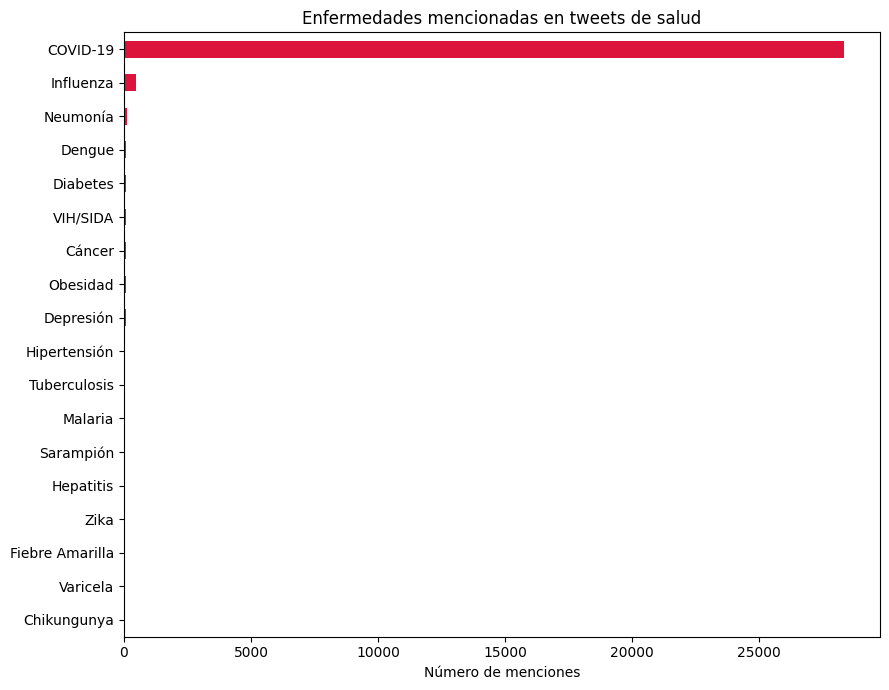

[GUARDADO] fig_top_enfermedades_salud.png
     Enfermedad  Frecuencia
       COVID-19       28333
      Influenza         465
       Neumonía         109
         Dengue          99
       Diabetes          95
       VIH/SIDA          94
         Cáncer          90
       Obesidad          75
      Depresión          69
   Hipertensión          60
   Tuberculosis          44
        Malaria          27
      Sarampión          21
      Hepatitis          12
           Zika          11
Fiebre Amarilla           9
       Varicela           5
    Chikungunya           3


In [10]:
# ============================================================
# CELL 5c — TOP ENFERMEDADES
# ============================================================

freq_enf = (
    df_res_enf.groupby('Enfermedad').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_enf.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Enfermedad', y='Frecuencia', ax=ax, color='crimson', legend=False
)
ax.set_title('Enfermedades mencionadas en tweets de salud')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_enfermedades_salud.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_enfermedades_salud.png')
print(freq_enf.to_string(index=False))


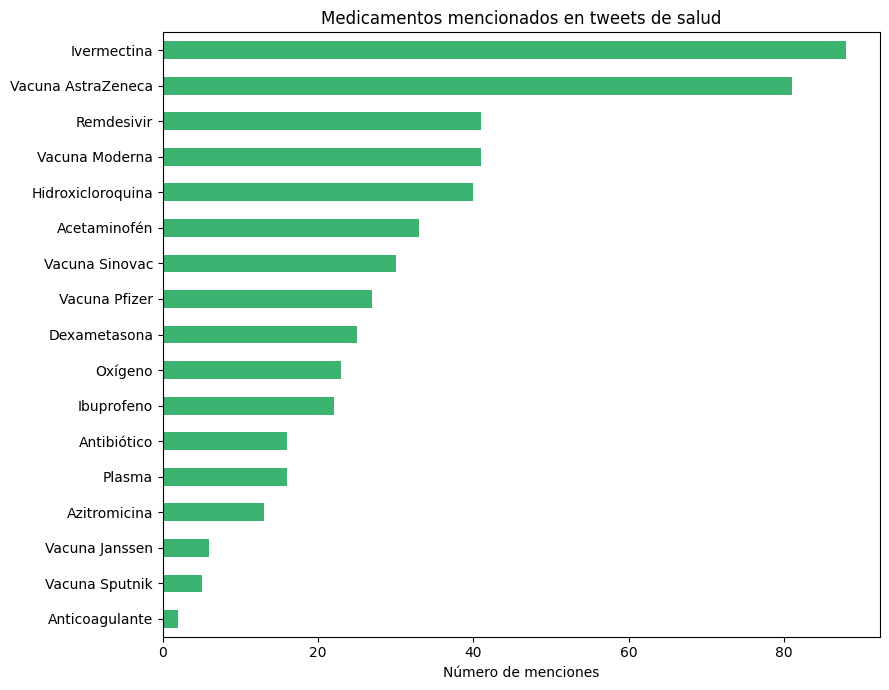

[GUARDADO] fig_top_medicamentos_salud.png
       Medicamento  Frecuencia
       Ivermectina          88
Vacuna AstraZeneca          81
        Remdesivir          41
    Vacuna Moderna          41
 Hidroxicloroquina          40
      Acetaminofén          33
    Vacuna Sinovac          30
     Vacuna Pfizer          27
      Dexametasona          25
           Oxígeno          23
        Ibuprofeno          22
       Antibiótico          16
            Plasma          16
      Azitromicina          13
    Vacuna Janssen           6
    Vacuna Sputnik           5
    Anticoagulante           2


In [11]:
# ============================================================
# CELL 5d — TOP MEDICAMENTOS
# ============================================================

freq_med = (
    df_res_med.groupby('Medicamento').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
freq_med.sort_values('Frecuencia', ascending=True).plot.barh(
    x='Medicamento', y='Frecuencia', ax=ax, color='mediumseagreen', legend=False
)
ax.set_title('Medicamentos mencionados en tweets de salud')
ax.set_xlabel('Número de menciones')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_top_medicamentos_salud.png', dpi=300)
plt.show()
print('[GUARDADO] fig_top_medicamentos_salud.png')
print(freq_med.to_string(index=False))


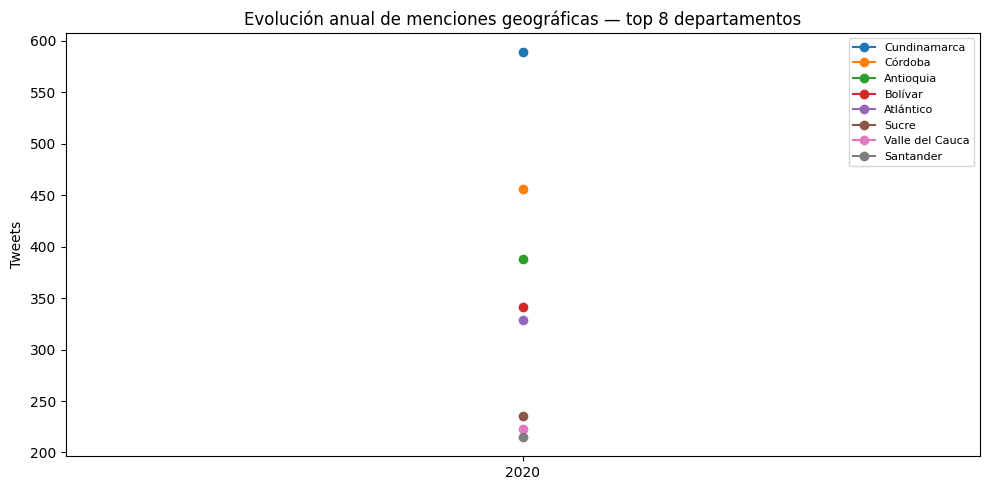

[GUARDADO] fig_evolucion_departamentos.png


In [12]:
# ============================================================
# CELL 7 — EVOLUCIÓN TEMPORAL DE LUGARES E INSTITUCIONES
# ============================================================
df_res_depto['Anio'] = pd.to_datetime(df_res_depto['Fecha']).dt.year

evol_depto = (
    df_res_depto.groupby(['Anio', 'Departamento']).size()
    .reset_index(name='n')
)

# Top 8 departamentos para la visualización
top8_deptos = freq_depto.head(8)['Departamento'].tolist()
evol_depto_top = evol_depto[evol_depto['Departamento'].isin(top8_deptos)]

fig, ax = plt.subplots(figsize=(10, 5))
for depto in top8_deptos:
    sub = evol_depto_top[evol_depto_top['Departamento'] == depto]
    ax.plot(sub['Anio'].astype(str), sub['n'], marker='o', label=depto)

ax.set_title('Evolución anual de menciones geográficas — top 8 departamentos')
ax.set_ylabel('Tweets')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(DATA_PROCESSED / 'fig_evolucion_departamentos.png', dpi=300)
plt.show()
print('[GUARDADO] fig_evolucion_departamentos.png')


In [13]:
# ============================================================
# CELL 8 — NER: ANÁLISIS DE ENTIDADES LOC DESDE salud_ner
# (complementa la búsqueda por regex con las entidades ya extraídas)
# ============================================================
salud_ner = pd.read_parquet(DATA_PROCESSED / 'salud_ner.parquet')

# Aplanar entidades LOC
loc_rows = []
for _, row in salud_ner.iterrows():
    for ent in row['entidades']:
        if len(ent) == 2 and ent[0] == 'LOC':
            loc_rows.append({
                'id_doc'   : row['id_doc'],
                'Anio'     : row['Anio'],
                'Entidad'  : str(ent[1]).strip(),
            })

df_loc_ner = pd.DataFrame(loc_rows)

freq_loc = (
    df_loc_ner.groupby('Entidad').size()
    .reset_index(name='Frecuencia')
    .sort_values('Frecuencia', ascending=False)
)

print(f'Entidades LOC (NER) en subcorpus de salud: {len(df_loc_ner):,} menciones')
print(f'Entidades únicas: {freq_loc["Entidad"].nunique():,}')
print()
print('Top 20 lugares (NER):')
print(freq_loc.head(20).to_string(index=False))


Entidades LOC (NER) en subcorpus de salud: 27,851 menciones
Entidades únicas: 6,500

Top 20 lugares (NER):
       Entidad  Frecuencia
         China        2286
      Colombia        2235
        Madrid         707
        México         448
        Bogotá         432
     Andalucía         390
          Cuba         296
       Córdoba         295
         Wuhan         287
          EEUU         218
        Brasil         211
     Antioquia         177
  Barranquilla         173
         Rusia         173
      Medellín         169
          Cali         168
Estados Unidos         168
     Cartagena         156
   Puerto Rico         155
         Sucre         141


In [14]:
# ============================================================
# CELL 9 — GUARDAR TODOS LOS RESULTADOS
# ============================================================

# Asegurar tipos string para parquet
def limpiar_para_parquet(df, cols_str):
    for col in cols_str:
        if col in df.columns:
            df[col] = df[col].astype(str)
    return df

df_res_depto   = limpiar_para_parquet(df_res_depto,   ['Departamento', 'Texto_limpio', 'Variante_hallada'])
df_res_inst    = limpiar_para_parquet(df_res_inst,    ['Institucion',  'Texto_limpio', 'Variante_hallada'])
df_res_autores = limpiar_para_parquet(df_res_autores, ['Autor_salud',  'Texto_limpio', 'Variante_hallada'])
df_res_enf     = limpiar_para_parquet(df_res_enf,     ['Enfermedad',   'Texto_limpio', 'Variante_hallada'])
df_res_med     = limpiar_para_parquet(df_res_med,     ['Medicamento',  'Texto_limpio', 'Variante_hallada'])

df_res_depto.to_parquet(DATA_PROCESSED / 'resultados_departamentos_salud.parquet', index=False)
df_res_inst.to_parquet(DATA_PROCESSED   / 'resultados_instituciones_salud.parquet', index=False)
df_res_autores.to_parquet(DATA_PROCESSED / 'resultados_autores_salud.parquet', index=False)
df_res_enf.to_parquet(DATA_PROCESSED    / 'resultados_enfermedades_salud.parquet', index=False)
df_res_med.to_parquet(DATA_PROCESSED    / 'resultados_medicamentos_salud.parquet', index=False)

ruta_excel = DATA_PROCESSED / 'busqueda_terminos_salud.xlsx'
with pd.ExcelWriter(ruta_excel, engine='openpyxl') as writer:
    freq_depto.to_excel(writer,   sheet_name='Departamentos',   index=False)
    freq_inst.to_excel(writer,    sheet_name='Instituciones',   index=False)
    freq_autores.to_excel(writer, sheet_name='Autores',         index=False)
    freq_enf.to_excel(writer,     sheet_name='Enfermedades',    index=False)
    freq_med.to_excel(writer,     sheet_name='Medicamentos',    index=False)
    freq_loc.head(100).to_excel(writer, sheet_name='LOC_NER',   index=False)
    df_res_depto.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_departamentos', index=False)
    df_res_inst.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_instituciones', index=False)
    df_res_autores.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_autores', index=False)
    df_res_enf.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_enfermedades', index=False)
    df_res_med.drop(columns=['Texto_limpio'], errors='ignore').to_excel(
        writer, sheet_name='Menciones_medicamentos', index=False)

print('[GUARDADO] 5 archivos .parquet')
print(f'[GUARDADO] {ruta_excel.name}  ({ruta_excel})')
print()
print('Notebook 10 completado.')
print('Siguiente -> 11_descriptivos_avanzados_salud.ipynb')


[GUARDADO] 5 archivos .parquet
[GUARDADO] busqueda_terminos_salud.xlsx  (C:\Users\afpue\Documents\GitHub\icare\kMetodo\resultadosPropios\busqueda_terminos_salud.xlsx)

Notebook 10 completado.
Siguiente -> 11_descriptivos_avanzados_salud.ipynb
